# Planetary-dominated eddies: vertical background flow and tilt

This notebook asks whether depth-dependent environmental flow can explain the shared zonal component of planetary-dominated eddy tilt, while the beta effect explains the opposite meridional components. It uses exactly the same 2:1 planetary-dominance, 3000 m minimum depth, and 5 km minimum tilt criteria as `plan_topo_dom_eddies/planetary_dominated_eddies.ipynb`.

`TiltDir` is a compass bearing **from the deep centre to the shallow centre** (0° north, 90° east). Therefore the kinematic predictor is shallow flow minus deep flow. A deeper layer flowing farther west than the surface gives a positive/eastward predictor, matching an eastward shallow-relative-to-deep tilt.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import statsmodels.formula.api as smf

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or one of its subfolders.')
FLOW_ROOT = ANALYSIS_ROOT / 'beta_effect_background_flow'
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
for path in (ANALYSIS_ROOT, FLOW_ROOT, CASE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from analysis_tools import add_track_velocity
from background_flow_tools import BackgroundConfig, load_background_cache
from vertical_propagation_tools import interpolate_centres, add_depth_propagation, wide_depth_propagation
from case_study_tools import PVAlignmentConfig, add_pv_alignment_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

## 1. Settings and exact planetary-dominated sample

In [2]:
DOMINANCE_FACTOR = 2.0
MIN_DEPTH_m = 3000.0
MIN_TILT_km = 5.0
PRIMARY_FAMILY = 'clim'      # centred 91-day moving seasonal climatology
FAMILIES = ('clim', 'full')
N_BOOT = 5000
RANDOM_SEED = 42

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
eddies, _ = tilt.load_tilt_tables(paths)
eddies = tilt.add_region_labels(eddies, grid)
eddies = tilt.add_pv_gradient_terms(eddies, grid, core_mean=True)

# Calculate track derivatives before filtering so boundary days are not created artificially.
eddies = add_track_velocity(eddies, grid.angle, window=5)
background = load_background_cache(BackgroundConfig())
required = {f'{family}_{depth}_{component}_ms' for family in FAMILIES
            for depth in ('surface', '200', '500') for component in ('east', 'north')}
missing = required - set(background.columns)
if missing:
    raise RuntimeError(f'Background cache is missing {sorted(missing)}. Run 01_build_background_cache.ipynb first.')
# d = eddies.merge(background, on=['Eddy', 'Day'], how='inner', validate='one_to_one')
background_for_merge = background.drop(columns=['ic', 'jc'], errors='ignore')
d = eddies.merge(background_for_merge, on=['Eddy', 'Day'], how='inner', validate='one_to_one')
pv_config = PVAlignmentConfig(dominance_factor=DOMINANCE_FACTOR,
                              min_open_ocean_depth_m=MIN_DEPTH_m,
                              min_tilt_distance_km=MIN_TILT_km)
d = add_pv_alignment_diagnostics(d, pv_config)
planetary = d[d.open_ocean_planetary & d.direction_valid].copy()
theta = np.deg2rad(planetary.TiltDir.astype(float))
planetary['tilt_east_km'] = planetary.TiltDis * np.sin(theta)
planetary['tilt_north_km'] = planetary.TiltDis * np.cos(theta)
display(planetary.groupby('Cyc').agg(observations=('Eddy','size'), eddies=('Eddy','nunique'),
    median_depth_m=('h','median'), median_tilt_east_km=('tilt_east_km','median'),
    median_tilt_north_km=('tilt_north_km','median')).round(2))

,observations,eddies,median_depth_m,median_tilt_east_km,median_tilt_north_km
Cyc,,,,,
AE,5184,364,4837.76,2.51,6.02
CE,1069,146,4853.47,5.16,-9.72


## 2. Construct physically interpretable layers and shear

The cache contains a surface value and thickness-weighted 0–200 m and 0–500 m means. Because every selected water column is deeper than 3000 m, the 200–500 m mean can be recovered as `(500 × mean_0_500 − 200 × mean_0_200) / 300`. This is a **layer mean**, not a velocity at a single sigma or z level.

The principal predictor is `surface − 200–500 m`, because the measured tilt points from deep to shallow. Positive east shear predicts eastward tilt; positive north shear predicts northward tilt. `clim` is the centred 91-day moving seasonal climatology and is the primary environmental-flow estimate; `full` is the full 26-year mean sensitivity test. The annulus method is excluded.

In [3]:
for family in FAMILIES:
    for component in ('east', 'north'):
        surface = f'{family}_surface_{component}_ms'
        upper = f'{family}_200_{component}_ms'
        full500 = f'{family}_500_{component}_ms'
        deep = f'{family}_200_500_{component}_ms'
        planetary[deep] = (500 * planetary[full500] - 200 * planetary[upper]) / 300
        planetary[f'{family}_surface_minus_200_{component}_ms'] = planetary[surface] - planetary[upper]
        planetary[f'{family}_surface_minus_deep_{component}_ms'] = planetary[surface] - planetary[deep]
        planetary[f'{family}_upper_minus_deep_{component}_ms'] = planetary[upper] - planetary[deep]
        # These are track velocities relative to different environmental references,
        # not independent measurements of the shallow and deep eddy-centre motion.
        planetary[f'{family}_surface_residual_{component}_ms'] = planetary[f'track_{component}_ms'] - planetary[surface]
        planetary[f'{family}_deep_residual_{component}_ms'] = planetary[f'track_{component}_ms'] - planetary[deep]

depth_labels = {'surface': 'Surface', '200': '0–200 m', '200_500': '200–500 m'}
planetary.filter(regex='^(Eddy|Day|Cyc|Tilt|tilt_|clim_.*(east|north)_ms)$').head()

,Eddy,Day,Cyc,clim_surface_east_ms,clim_surface_north_ms,clim_200_east_ms,clim_200_north_ms,clim_500_east_ms,clim_500_north_ms,clim_200_500_east_ms,clim_surface_minus_200_east_ms,clim_surface_minus_deep_east_ms,clim_upper_minus_deep_east_ms,clim_surface_residual_east_ms,clim_deep_residual_east_ms,clim_200_500_north_ms,clim_surface_minus_200_north_ms,clim_surface_minus_deep_north_ms,clim_upper_minus_deep_north_ms,clim_surface_residual_north_ms,clim_deep_residual_north_ms
158,6,1465,AE,0.081333,0.011343,0.059480,0.037867,0.039407,0.031878,0.026024,0.021853,0.055308,0.033455,-0.048632,0.006676,0.027885,-0.026524,-0.016542,0.009982,0.020001,0.003458
159,6,1466,AE,0.064961,-0.008974,0.045286,0.020039,0.028523,0.017809,0.017348,0.019675,0.047613,0.027938,-0.080358,-0.032745,0.016323,-0.029013,-0.025297,0.003716,0.057823,0.032527
160,6,1467,AE,0.072867,-0.015649,0.053002,0.014625,0.033558,0.014060,0.020595,0.019864,0.052271,0.032407,-0.088264,-0.035992,0.013683,-0.030274,-0.029332,0.000942,0.064498,0.035166
161,6,1468,AE,0.025780,-0.076440,0.011044,-0.038365,0.000427,-0.028040,-0.006652,0.014736,0.032432,0.017696,-0.041177,-0.008745,-0.021156,-0.038075,-0.055283,-0.017208,0.125289,0.070006
162,6,1469,AE,0.016842,-0.079676,0.003836,-0.041382,-0.004417,-0.030974,-0.009919,0.013006,0.026761,0.013755,-0.048327,-0.021566,-0.024036,-0.038294,-0.055640,-0.017346,0.137370,0.081729


## 3. Flow at each depth

The bars use one median per eddy and then summarize eddies, avoiding long-lived eddies dominating the result. Compare AE and CE at each depth. Similar eastward profiles support a shared zonal mechanism; opposite northward profiles would support polarity-dependent sampling or dynamics.

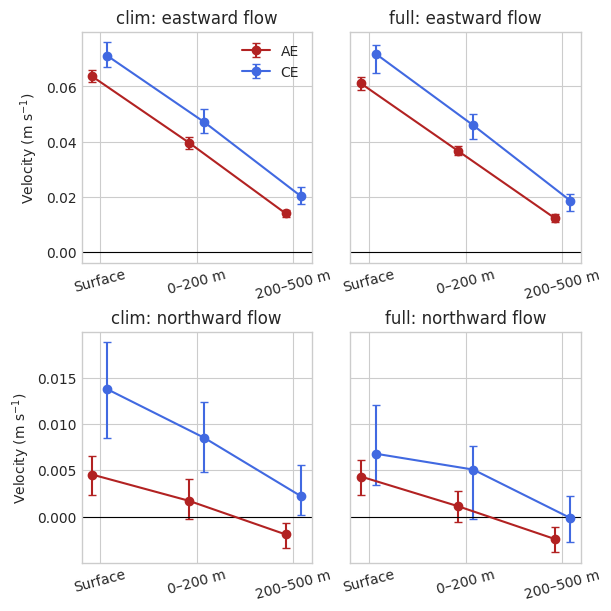

In [52]:
def eddy_medians(frame, columns):
    return frame.groupby(['Cyc', 'Eddy'], as_index=False)[columns].median(numeric_only=True)

def bootstrap_median(values, n_boot=N_BOOT, seed=RANDOM_SEED):
    values = np.asarray(values, float)
    values = values[np.isfinite(values)]
    if not len(values):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = np.median(rng.choice(values, (n_boot, len(values)), replace=True), axis=1)
    return np.median(values), *np.percentile(boot, [2.5, 97.5])

def depth_summary(frame, family):
    rows = []
    for component in ('east', 'north'):
        for depth in depth_labels:
            col = f'{family}_{depth}_{component}_ms'
            em = frame #eddy_medians(frame, [col])
            for cyc, part in em.groupby('Cyc'):
                med, lo, hi = bootstrap_median(part[col], seed=RANDOM_SEED + len(rows))
                rows.append(dict(family=family, component=component, depth=depth, Cyc=cyc,
                                 eddies=part[col].notna().sum(), median=med, ci_low=lo, ci_high=hi))
    return pd.DataFrame(rows)

flow_summary = pd.concat([depth_summary(planetary, f) for f in FAMILIES], ignore_index=True)
# display(flow_summary.round(4))

fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharey='row', constrained_layout=True)
colors = {'AE': 'firebrick', 'CE': 'royalblue'}
for j, family in enumerate(FAMILIES):
    for i, component in enumerate(('east', 'north')):
        ax = axes[i, j]
        part = flow_summary.query('family == @family and component == @component')
        for offset, cyc in zip((-0.08, 0.08), ('AE', 'CE')):
            q = part[part.Cyc.eq(cyc)].set_index('depth').reindex(depth_labels)
            x = np.arange(3) + offset
            ax.errorbar(x, q['median'], yerr=[q['median']-q['ci_low'], q['ci_high']-q['median']],
                        fmt='o-', capsize=3, color=colors[cyc], label=cyc)
        ax.axhline(0, color='k', lw=.8)
        ax.set_xticks(range(3), depth_labels.values(), rotation=15)
        ax.set_title(f'{family}: {component}ward flow')
        if j == 0: ax.set_ylabel('Velocity (m s$^{-1}$)')
        if i == 0 and j == 0: ax.legend()
plt.show()

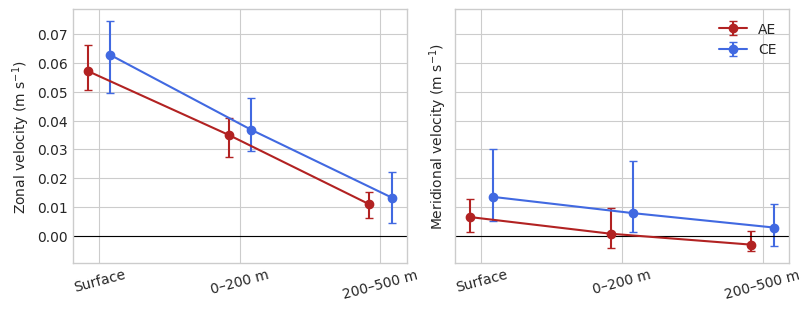

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey='row', constrained_layout=True)
colors = {'AE': 'firebrick', 'CE': 'royalblue'}
family = 'clim'
for (ax, component) in zip(axs, ('east', 'north')):
    part = flow_summary.query('family == @family and component == @component')
    for offset, cyc in zip((-0.08, 0.08), ('AE', 'CE')):
        q = part[part.Cyc.eq(cyc)].set_index('depth').reindex(depth_labels)
        x = np.arange(3) + offset
        ax.errorbar(x, q['median'], yerr=[q['median']-q['ci_low'], q['ci_high']-q['median']],
                    fmt='o-', capsize=3, color=colors[cyc], label=cyc)
    ax.axhline(0, color='k', lw=.8)
    ax.set_xticks(range(3), depth_labels.values(), rotation=15)
    if component == 'east':
        ax.set_ylabel('Zonal velocity (m s$^{-1}$)')
    else:
        ax.set_ylabel('Meridional velocity (m s$^{-1}$)')
        ax.legend()


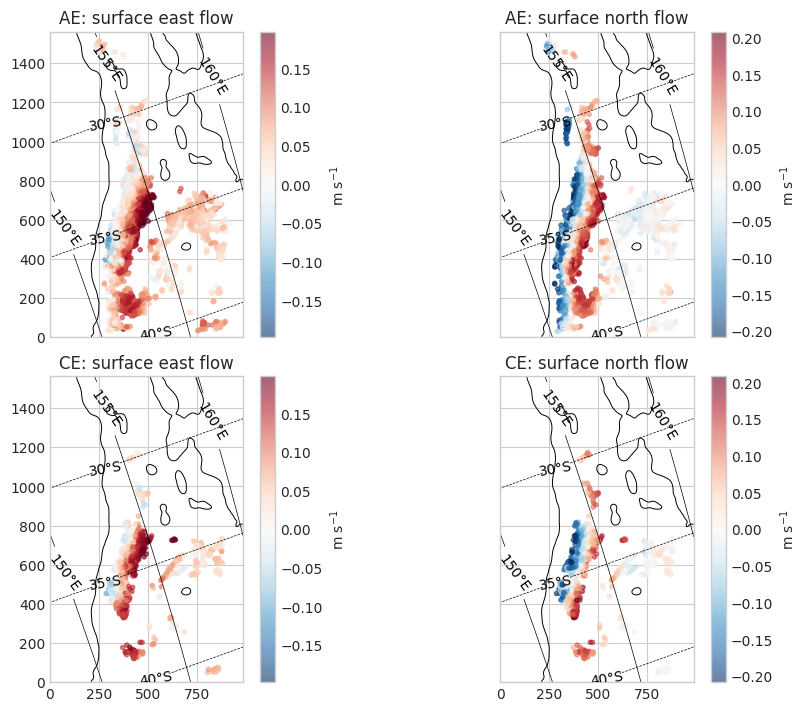

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True, constrained_layout=True)
family = 'clim'
depth = 'surface'
for i, cyc in enumerate(('AE', 'CE')):
    q = planetary[planetary.Cyc.eq(cyc)]
    for j, title in enumerate(('east', 'north')):
        col = f'{family}_{depth}_{title}_ms'
        ax = axes[i, j]
        lim = np.nanpercentile(np.abs(planetary[col]), 98)
        sc = ax.scatter(q.xc, q.yc, c=q[col], s=9, alpha=.6, cmap='RdBu_r', vmin=-lim, vmax=lim)
        ax.contour(grid.X_grid, grid.Y_grid, grid.h, levels=[MIN_DEPTH_m], colors='k', linewidths=.7)
        tilt.lat_lon_contours(ax, grid)
        ax.set_title(f'{cyc}: {depth} {title} flow')
        ax.set_aspect('equal', adjustable='box')
        fig.colorbar(sc, ax=ax, label='m s$^{-1}$')
plt.show()

## 4. Does surface-minus-deep shear have the observed tilt direction?

The first panel compares the AE/CE median shear vectors with the observed tilt vectors. Arrow directions, rather than lengths, are directly comparable because velocity and displacement have different units. The second and third panels test zonal and meridional components at the eddy level.

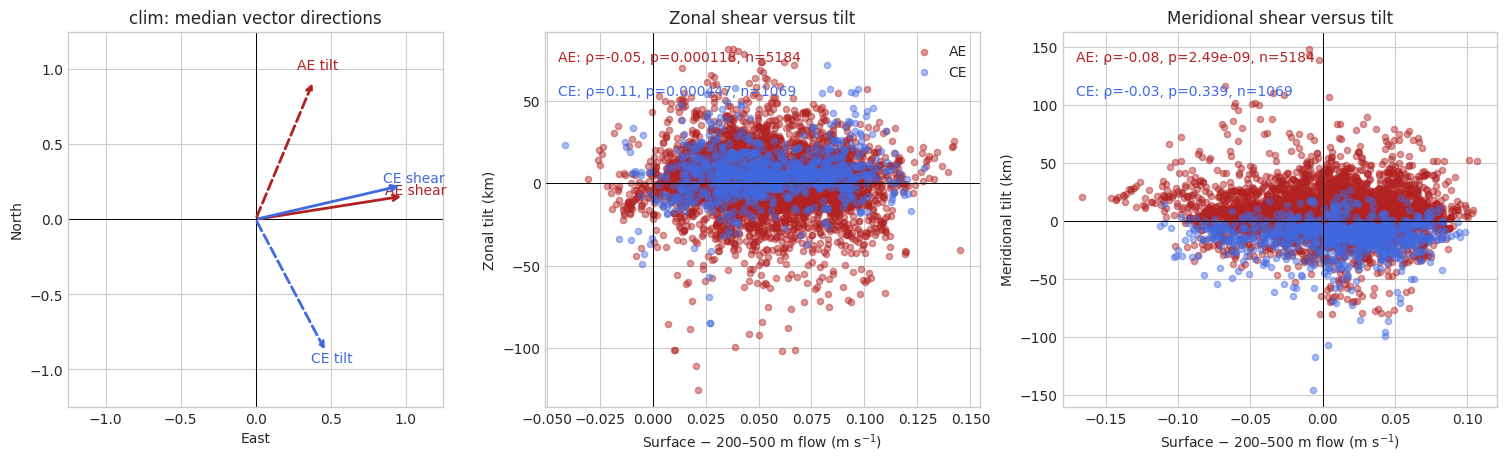

In [49]:
family = PRIMARY_FAMILY
shear_e = f'{family}_surface_minus_deep_east_ms'
shear_n = f'{family}_surface_minus_deep_north_ms'
cols = ['tilt_east_km', 'tilt_north_km', shear_e, shear_n]
eddy_level = planetary #eddy_medians(planetary, cols)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
ax = axes[0]
for cyc in ('AE', 'CE'):
    q = eddy_level[eddy_level.Cyc.eq(cyc)]
    se, sn = q[[shear_e, shear_n]].median()
    te, tn = q[['tilt_east_km', 'tilt_north_km']].median()
    # Normalize each arrow: this panel compares direction only.
    for e, n, ls, label in ((se, sn, '-', f'{cyc} shear'), (te, tn, '--', f'{cyc} tilt')):
        norm = np.hypot(e, n)
        ax.annotate('', xy=(e/norm, n/norm), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=colors[cyc], lw=2, linestyle=ls))
        ax.text(e/norm*1.08, n/norm*1.08, label, color=colors[cyc], ha='center')
ax.axhline(0, color='k', lw=.7); ax.axvline(0, color='k', lw=.7)
ax.set(xlim=(-1.25,1.25), ylim=(-1.25,1.25), aspect='equal', xlabel='East', ylabel='North',
       title=f'{family}: median vector directions')

for ax, xcol, ycol, label in ((axes[1], shear_e, 'tilt_east_km', 'zonal'),
                                  (axes[2], shear_n, 'tilt_north_km', 'meridional')):
    for cyc in ('AE', 'CE'):
        q = eddy_level[eddy_level.Cyc.eq(cyc)]
        ax.scatter(q[xcol], q[ycol], s=20, alpha=.45, color=colors[cyc], label=cyc)
        valid = q[[xcol, ycol]].dropna()
        rho, p = spearmanr(valid[xcol], valid[ycol]) if len(valid) > 2 else (np.nan, np.nan)
        ax.text(.03, .95-(.09 if cyc == 'CE' else 0), f'{cyc}: ρ={rho:.2f}, p={p:.3g}, n={len(valid)}',
                transform=ax.transAxes, va='top', color=colors[cyc])
    ax.axhline(0, color='k', lw=.7); ax.axvline(0, color='k', lw=.7)
    ax.set_xlabel('Surface − 200–500 m flow (m s$^{-1}$)')
    ax.set_ylabel(f'{label.capitalize()} tilt (km)')
    ax.set_title(f'{label.capitalize()} shear versus tilt')
axes[1].legend()
plt.show()

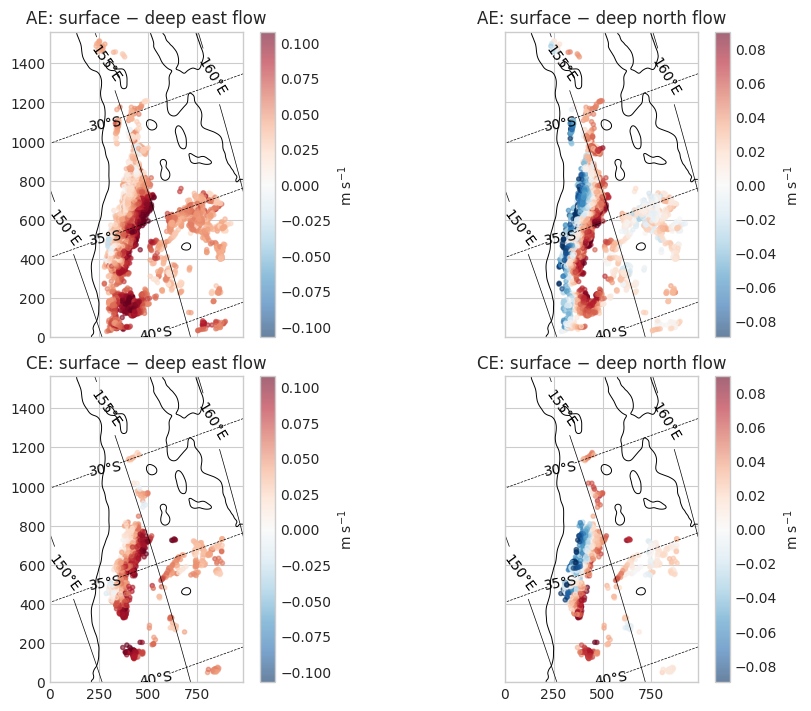

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True, constrained_layout=True)
for i, cyc in enumerate(('AE', 'CE')):
    q = planetary[planetary.Cyc.eq(cyc)]
    for j, (col, title) in enumerate(((shear_e, 'east'), (shear_n, 'north'))):
        ax = axes[i, j]
        lim = np.nanpercentile(np.abs(planetary[col]), 98)
        sc = ax.scatter(q.xc, q.yc, c=q[col], s=9, alpha=.6, cmap='RdBu_r', vmin=-lim, vmax=lim)
        ax.contour(grid.X_grid, grid.Y_grid, grid.h, levels=[MIN_DEPTH_m], colors='k', linewidths=.7)
        tilt.lat_lon_contours(ax, grid)
        ax.set_title(f'{cyc}: surface − deep {title} flow')
        ax.set_aspect('equal', adjustable='box')
        fig.colorbar(sc, ax=ax, label='m s$^{-1}$')
plt.show()

## 5. Whole-eddy bootstrap tests

A positive zonal shear median means that the surface environment is eastward relative to 200–500 m and therefore predicts eastward tilt. For the meridional component, the beta-effect prediction is made polarity-aware: northward for AEs and southward for CEs. Confidence intervals resample entire eddies. The correlation test also resamples eddies and is more defensible than treating eddy-days as independent.

In [6]:
def bootstrap_correlation(frame, x, y, n_boot=N_BOOT, seed=RANDOM_SEED):
    # `frame` already contains one row per eddy: resample rows directly.
    q = frame[[x, y]].dropna().to_numpy(float)
    if len(q) < 3:
        return np.nan, np.nan, np.nan
    observed = spearmanr(q[:, 0], q[:, 1]).statistic
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        sample = q[rng.integers(0, len(q), len(q))]
        boot[b] = spearmanr(sample[:, 0], sample[:, 1]).statistic
    return observed, *np.nanpercentile(boot, [2.5, 97.5])

records = []
for family in FAMILIES:
    for cyc in ('AE', 'CE'):
        q = planetary[planetary.Cyc.eq(cyc)].copy()
        q['beta_aligned_shear_ms'] = np.where(cyc == 'AE', 1, -1) * q[f'{family}_surface_minus_deep_north_ms']
        q['beta_aligned_tilt_km'] = np.where(cyc == 'AE', 1, -1) * q['tilt_north_km']
        em = eddy_medians(q, [f'{family}_surface_minus_deep_east_ms', 'tilt_east_km',
                                'beta_aligned_shear_ms', 'beta_aligned_tilt_km'])
        for mechanism, x, y in (
            ('zonal', f'{family}_surface_minus_deep_east_ms', 'tilt_east_km'),
            ('beta-aligned meridional', 'beta_aligned_shear_ms', 'beta_aligned_tilt_km')):
            med, lo, hi = bootstrap_median(em[x], seed=RANDOM_SEED + len(records))
            rho, rho_lo, rho_hi = bootstrap_correlation(em, x, y, seed=RANDOM_SEED + len(records))
            records.append(dict(family=family, Cyc=cyc, mechanism=mechanism, eddies=len(em),
                median_predictor=med, predictor_ci_low=lo, predictor_ci_high=hi,
                spearman_rho=rho, rho_ci_low=rho_lo, rho_ci_high=rho_hi))
tests = pd.DataFrame(records)
display(tests.round(4))

,family,Cyc,mechanism,eddies,median_predictor,predictor_ci_low,predictor_ci_high,spearman_rho,rho_ci_low,rho_ci_high
0,clim,AE,zonal,364,0.0486,0.0455,0.0517,-0.2034,-0.2981,-0.1009
1,clim,AE,beta-aligned meridional,364,0.0106,0.0064,0.0142,-0.0539,-0.1539,0.0418
2,clim,CE,zonal,146,0.0492,0.0449,0.0566,0.0078,-0.1629,0.1816
3,clim,CE,beta-aligned meridional,146,-0.0152,-0.0242,-0.0093,0.0918,-0.0766,0.2546
4,full,AE,zonal,364,0.0475,0.0445,0.0496,-0.1391,-0.2465,-0.0299
5,full,AE,beta-aligned meridional,364,0.0090,0.0073,0.0118,-0.0511,-0.1546,0.0510
6,full,CE,zonal,146,0.0510,0.0441,0.0541,0.0435,-0.1315,0.2214
7,full,CE,beta-aligned meridional,146,-0.0098,-0.0162,-0.0072,0.0864,-0.0753,0.2461


## 6. Natural/background-relative westward propagation

Negative eastward residual velocity means the tracked eddy propagates westward relative to that background estimate. This checks whether the planetary eddies retain a westward propagation anomaly after removing the flow. However, there is only one tracked horizontal centre velocity per eddy-day: subtracting surface and deep backgrounds does **not** independently observe top and bottom eddy propagation. Consequently, the difference between these residuals is algebraically the negative of the background shear and should not be treated as a second independent shear test.

,family,component,reference,Cyc,median,ci_low,ci_high,eddies
0,clim,east,surface,AE,-0.0634,-0.0732,-0.0542,364
1,clim,east,surface,CE,-0.0881,-0.1100,-0.0710,146
2,clim,east,deep,AE,-0.0181,-0.0250,-0.0108,364
3,clim,east,deep,CE,-0.0378,-0.0497,-0.0247,146
4,clim,north,surface,AE,-0.0199,-0.0289,-0.0106,364
5,clim,north,surface,CE,-0.0438,-0.0617,-0.0175,146
6,clim,north,deep,AE,-0.0070,-0.0142,-0.0019,364
7,clim,north,deep,CE,-0.0245,-0.0380,-0.0107,146
8,full,east,surface,AE,-0.0657,-0.0723,-0.0593,364
9,full,east,surface,CE,-0.0867,-0.1050,-0.0772,146


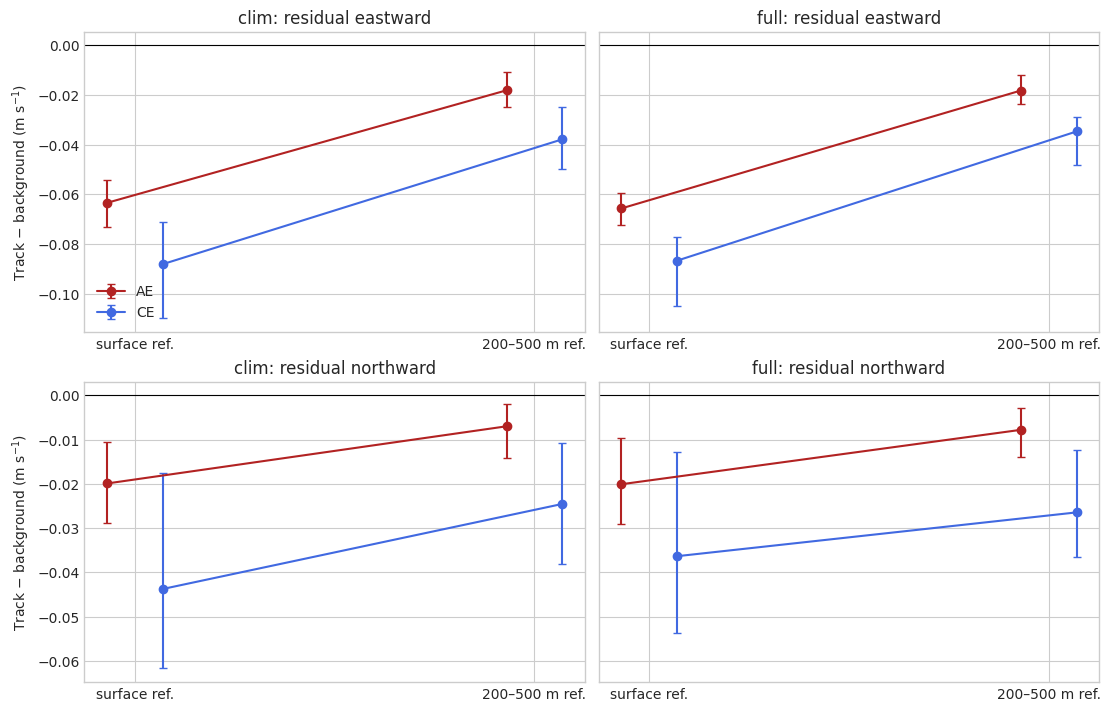

In [7]:
residual_cols = []
for family in FAMILIES:
    residual_cols += [f'{family}_surface_residual_east_ms', f'{family}_deep_residual_east_ms',
                      f'{family}_surface_residual_north_ms', f'{family}_deep_residual_north_ms']
residual_eddy = eddy_medians(planetary, residual_cols)
rows = []
for family in FAMILIES:
    for component in ('east', 'north'):
        for reference in ('surface', 'deep'):
            col = f'{family}_{reference}_residual_{component}_ms'
            for cyc, part in residual_eddy.groupby('Cyc'):
                med, lo, hi = bootstrap_median(part[col], seed=RANDOM_SEED + len(rows))
                rows.append(dict(family=family, component=component, reference=reference, Cyc=cyc,
                                 median=med, ci_low=lo, ci_high=hi, eddies=part[col].notna().sum()))
residual_summary = pd.DataFrame(rows)
display(residual_summary.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey='row', constrained_layout=True)
for j, family in enumerate(FAMILIES):
    for i, component in enumerate(('east', 'north')):
        ax = axes[i, j]
        p = residual_summary.query('family == @family and component == @component')
        for k, cyc in enumerate(('AE', 'CE')):
            q = p[p.Cyc.eq(cyc)].set_index('reference').reindex(['surface','deep'])
            x = np.arange(2) + (-.07 if cyc == 'AE' else .07)
            ax.errorbar(x, q['median'], yerr=[q['median']-q['ci_low'], q['ci_high']-q['median']],
                        fmt='o-', capsize=3, color=colors[cyc], label=cyc)
        ax.axhline(0, color='k', lw=.8)
        ax.set_xticks([0,1], ['surface ref.', '200–500 m ref.'])
        ax.set_title(f'{family}: residual {component}ward')
        if j == 0: ax.set_ylabel('Track − background (m s$^{-1}$)')
        if i == 0 and j == 0: ax.legend()
plt.show()

## 7. Latitude-controlled meridional propagation

The key beta-drift test is the **AE minus CE northward residual-velocity contrast**. A positive contrast means that AEs propagate more equatorward (or less poleward) than CEs. Both types may still move southward because beta drift is superimposed on the EAC and other steering. The binned analysis compares whole eddies within the same latitude ranges. The GEE model uses all eddy-days, a flexible latitude spline, and eddy-clustered uncertainty; latitude is the only adjustment variable.

,family,reference,latitude,latitude_bin,ae_eddies,ce_eddies,ae_median,ce_median,ae_minus_ce,ci_low,ci_high
0,clim,surface,-40.5548,"(-42.001, -40.0]",7,1,0.0061,0.0234,NaN,NaN,NaN
1,clim,surface,-38.4507,"(-40.0, -38.0]",76,19,-0.0800,-0.0816,0.0016,-0.0122,0.0721
2,clim,surface,-36.3903,"(-38.0, -36.0]",121,35,-0.0198,-0.0838,0.0641,0.0241,0.0975
3,clim,surface,-35.1932,"(-36.0, -34.0]",164,81,-0.0015,-0.0141,0.0126,-0.0189,0.0363
4,clim,surface,-33.5423,"(-34.0, -32.0]",89,27,0.0213,-0.0002,0.0215,-0.0318,0.1244
5,clim,surface,-31.1009,"(-32.0, -30.0]",25,7,-0.0369,-0.1348,0.0979,0.0085,0.1204
6,clim,surface,-29.8920,"(-30.0, -28.0]",7,3,-0.0663,-0.0877,0.0214,-0.0433,0.1327
7,clim,surface,-26.6663,"(-28.0, -26.0]",6,0,-0.0168,NaN,NaN,NaN,NaN
8,clim,deep,-40.5548,"(-42.001, -40.0]",7,1,0.0137,0.0352,NaN,NaN,NaN
9,clim,deep,-38.4507,"(-40.0, -38.0]",76,19,-0.0269,-0.0351,0.0083,-0.0052,0.0648


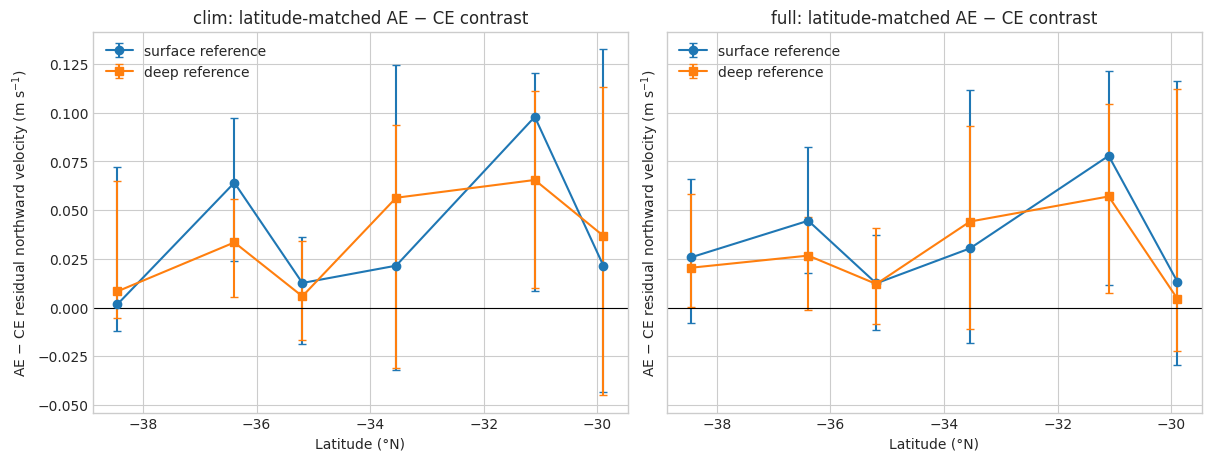

,family,reference,observations,eddies,ce_minus_ae_ms,ci_low,ci_high,p_value
0,clim,surface,6253,510,-0.02733,-0.04586,-0.00879,0.00385
1,clim,deep,6253,510,-0.02013,-0.03324,-0.00703,0.00260
2,full,surface,6253,510,-0.02513,-0.04290,-0.00736,0.00558
3,full,deep,6253,510,-0.02162,-0.03461,-0.00863,0.00110


Expected beta-drift result: CE − AE is negative after controlling for latitude.


In [9]:
ii = planetary.ic.astype(int).clip(0, grid.lat_rho.shape[0] - 1)
jj = planetary.jc.astype(int).clip(0, grid.lat_rho.shape[1] - 1)
planetary['latitude'] = grid.lat_rho[ii, jj]
LAT_BIN_DEG = 2.0
lat_edges = np.arange(np.floor(planetary.latitude.min() / LAT_BIN_DEG) * LAT_BIN_DEG,
                      np.ceil(planetary.latitude.max() / LAT_BIN_DEG) * LAT_BIN_DEG + LAT_BIN_DEG,
                      LAT_BIN_DEG)
planetary['latitude_bin'] = pd.cut(planetary.latitude, lat_edges, include_lowest=True)

def bootstrap_two_group_contrast(a, b, n_boot=N_BOOT, seed=RANDOM_SEED):
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if min(len(a), len(b)) < 3:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = np.median(a[rng.integers(0, len(a), (n_boot, len(a)))], axis=1) - \
           np.median(b[rng.integers(0, len(b), (n_boot, len(b)))], axis=1)
    return np.median(a) - np.median(b), *np.percentile(boot, [2.5, 97.5])

latitude_rows = []
for family in FAMILIES:
    for reference in ('surface', 'deep'):
        col = f'{family}_{reference}_residual_north_ms'
        em = planetary.groupby(['latitude_bin','Cyc','Eddy'], observed=True, as_index=False).agg(
            latitude=('latitude','median'), residual_north_ms=(col,'median'))
        for band, part in em.groupby('latitude_bin', observed=True):
            ae = part.loc[part.Cyc.eq('AE'), 'residual_north_ms']
            ce = part.loc[part.Cyc.eq('CE'), 'residual_north_ms']
            contrast, lo, hi = bootstrap_two_group_contrast(ae, ce, seed=RANDOM_SEED + len(latitude_rows))
            latitude_rows.append(dict(family=family, reference=reference, latitude=part.latitude.median(),
                latitude_bin=str(band), ae_eddies=ae.notna().sum(), ce_eddies=ce.notna().sum(),
                ae_median=ae.median(), ce_median=ce.median(), ae_minus_ce=contrast, ci_low=lo, ci_high=hi))
latitude_contrasts = pd.DataFrame(latitude_rows)
display(latitude_contrasts.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True, constrained_layout=True)
for ax, family in zip(axes, FAMILIES):
    for reference, marker in (('surface','o'), ('deep','s')):
        q = latitude_contrasts.query('family == @family and reference == @reference').dropna(subset=['ae_minus_ce'])
        ax.errorbar(q.latitude, q.ae_minus_ce, yerr=[q.ae_minus_ce-q.ci_low, q.ci_high-q.ae_minus_ce],
                    marker=marker, capsize=3, label=f'{reference} reference')
    ax.axhline(0, color='k', lw=.8)
    ax.set(title=f'{family}: latitude-matched AE − CE contrast', xlabel='Latitude (°N)',
           ylabel='AE − CE residual northward velocity (m s$^{-1}$)')
    ax.legend()
plt.show()

model_rows = []
for family in FAMILIES:
    for reference in ('surface', 'deep'):
        response = f'{family}_{reference}_residual_north_ms'
        use = planetary[['Eddy','Cyc','latitude',response]].dropna().rename(columns={response:'v_res_north'})
        fit = smf.gee('v_res_north ~ C(Cyc) + bs(latitude, df=4)', groups='Eddy', data=use).fit()
        term = 'C(Cyc)[T.CE]'
        ci = fit.conf_int().loc[term]
        model_rows.append(dict(family=family, reference=reference, observations=len(use),
            eddies=use.Eddy.nunique(), ce_minus_ae_ms=fit.params[term], ci_low=ci.iloc[0],
            ci_high=ci.iloc[1], p_value=fit.pvalues[term]))
latitude_models = pd.DataFrame(model_rows)
display(latitude_models.round(5))
print('Expected beta-drift result: CE − AE is negative after controlling for latitude.')

## 8. Direct propagation of eddy centres at fixed depths

This is the stronger test. `tilt.load_vert()` contains fitted centre positions through the water column. Centres are interpolated to fixed physical depths (0, 200 and 500 m), differentiated along each eddy track, smoothed over five observations, and rotated from the model grid into geographic east/north. A positive `0 m − 500 m` eastward velocity difference means the shallow centre propagates farther east (or less westward) than the deep centre and directly predicts eastward tilt growth.

,centre_east_ms_0m,centre_east_ms_200m,centre_east_ms_500m,centre_north_ms_0m,centre_north_ms_200m,centre_north_ms_500m,direct_surface_minus_500_east_ms,direct_surface_minus_500_north_ms
Cyc,,,,,,,,
AE,-0.0029,-0.0110,-0.0124,-0.0029,-0.0043,-0.0052,0.0069,0.0014
CE,-0.0281,-0.0188,-0.0171,-0.0109,-0.0081,-0.0096,-0.0016,-0.0052


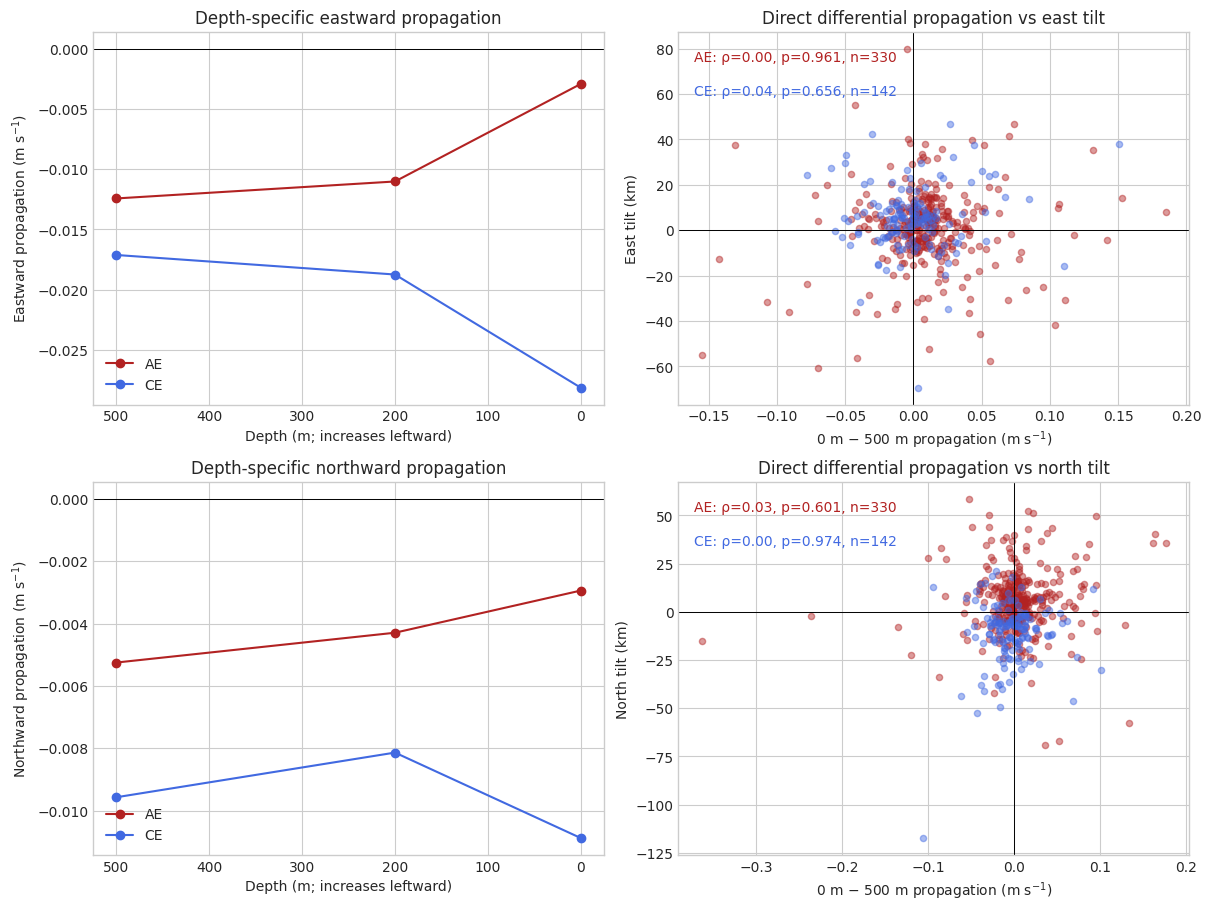

In [10]:
vertical = tilt.load_vert(paths)
centres = interpolate_centres(vertical, target_depths=(0.0, 200.0, 500.0))
centres = add_depth_propagation(centres, grid.angle, window=5)
depth_motion = wide_depth_propagation(centres)
planetary = planetary.merge(depth_motion, on=['Eddy','Day'], how='left', validate='one_to_one')
for component in ('east', 'north'):
    planetary[f'direct_surface_minus_500_{component}_ms'] = (
        planetary[f'centre_{component}_ms_0m'] - planetary[f'centre_{component}_ms_500m'])
    planetary[f'direct_surface_minus_200_{component}_ms'] = (
        planetary[f'centre_{component}_ms_0m'] - planetary[f'centre_{component}_ms_200m'])

direct_cols = [f'centre_{c}_ms_{z}m' for c in ('east','north') for z in (0,200,500)] + [
    f'direct_surface_minus_500_{c}_ms' for c in ('east','north')]
direct_eddy = eddy_medians(planetary, direct_cols + ['tilt_east_km','tilt_north_km'])
display(direct_eddy.groupby('Cyc')[direct_cols].median().round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for i, component in enumerate(('east','north')):
    ax = axes[i,0]
    for cyc in ('AE','CE'):
        q = direct_eddy[direct_eddy.Cyc.eq(cyc)]
        med = [q[f'centre_{component}_ms_{z}m'].median() for z in (0,200,500)]
        ax.plot((0,200,500), med, 'o-', color=colors[cyc], label=cyc)
    ax.axhline(0,color='k',lw=.7); ax.invert_xaxis()
    ax.set(xlabel='Depth (m; increases leftward)', ylabel=f'{component.capitalize()}ward propagation (m s$^{{-1}}$)',
           title=f'Depth-specific {component}ward propagation')
    ax.legend()
    ax = axes[i,1]
    x = f'direct_surface_minus_500_{component}_ms'
    y = f'tilt_{component}_km'
    for cyc in ('AE','CE'):
        q = direct_eddy[direct_eddy.Cyc.eq(cyc)].dropna(subset=[x,y])
        ax.scatter(q[x], q[y], s=20, alpha=.45, color=colors[cyc], label=cyc)
        rho, p = spearmanr(q[x], q[y]) if len(q)>2 else (np.nan,np.nan)
        ax.text(.03, .95-(.09 if cyc=='CE' else 0), f'{cyc}: ρ={rho:.2f}, p={p:.3g}, n={len(q)}',
                transform=ax.transAxes, va='top', color=colors[cyc])
    ax.axhline(0,color='k',lw=.7); ax.axvline(0,color='k',lw=.7)
    ax.set(xlabel='0 m − 500 m propagation (m s$^{-1}$)', ylabel=f'{component.capitalize()} tilt (km)',
           title=f'Direct differential propagation vs {component} tilt')
plt.show()

## 9. Interpretation guide

Evidence consistent with the proposed zonal mechanism would require: (1) surface-minus-deep eastward flow is positive for both AE and CE, with whole-eddy confidence intervals excluding zero; (2) the result agrees between the moving seasonal climatology and full-archive background; (3) eddies with stronger eastward shear tend to have larger eastward tilt; (4) the direct 0 m minus 500 m centre-propagation difference is eastward and predicts eastward tilt or tilt growth; and (5) the relationship is not explained by AE/CE location differences.

For the meridional beta-effect interpretation, AE predictors and tilts should be preferentially north/equatorward while CE predictors and tilts should be south/poleward. A directional median without a shear–tilt association is suggestive of a shared environment, but not evidence that shear causes tilt.

Keep the two tests conceptually separate: the cache describes environmental flow, whereas `load_vert()` provides the fitted centre positions used for direct depth-specific propagation. Agreement between them is much stronger evidence than either alone. Even then, association does not by itself establish causation, and derivatives of fitted daily centres can be noisy; inspect coverage, outliers and individual tracks before drawing a dynamical conclusion.